In [69]:
# importing libraries required.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv('mymoviedb.csv', engine = 'c', lineterminator="\n")

In [71]:
df.sample(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
510,2021-02-03,Please Enlighten Me,"A story between Lin Zhi Xiao, a graduating st...",103.591,1,2.0,zh,Romance,https://image.tmdb.org/t/p/original/sGbDFapR6X...
9548,2022-02-16,Chickenhare and the Hamster of Darkness,Young Chickenhare is the adopted son of King P...,13.590,5,6.4,en,"Adventure, Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/k7zuMPZVkK...
7013,2016-10-28,May God Save Us,"Madrid, summer 2011. Economic crisis. 15-M mov...",16.687,337,6.7,es,"Thriller, Crime, Action",https://image.tmdb.org/t/p/original/4TfKiRHBEJ...
3694,2008-09-30,I Am Iron Man,A documentary covering pre-production topics l...,25.902,57,7.3,en,Documentary,https://image.tmdb.org/t/p/original/81zROb3C2M...
9667,2017-03-03,Table 19,"Eloise, having been relieved of maid of honor ...",13.484,832,6.0,en,"Comedy, Drama",https://image.tmdb.org/t/p/original/5frbf55BlF...


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [73]:
 df['Genre'].sample(6)

9318    Action, Adventure, Crime, Science Fiction, Thr...
4200                               Drama, Science Fiction
2385                                               Comedy
5397                               Drama, Horror, Romance
9129                                               Horror
1814                                               Comedy
Name: Genre, dtype: object

In [74]:
df.duplicated().sum()

0

In [75]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


+ ## Exploration summary

+ The dataframe is consisting of 9827 rows and 9 columns.

+ The data has no duplicated values and no NaN's.

+ Release_Date column needs to be changed into date_time format to extract only the year value.

+ Dropped columns because of no use in analysis - Overview, Original_Language and Poster_Url.

+ Their is some noticiable Outliers in Popularity column.

+ Vote_Average column should be categorised for better analysis.

+ Genre column has comma separated values with white space after comma that should be handled and casted into category.

In [76]:
#Changing the release date column to date time format
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   int64         
 5   Vote_Average       9827 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9827 non-null   object        
 8   Poster_Url         9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 691.1+ KB


In [78]:
# We only need year in date so changing it to only year
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].head

<bound method NDFrame.head of 0       2021
1       2022
2       2022
3       2021
4       2021
        ... 
9822    1973
9823    2020
9824    2016
9825    2021
9826    1984
Name: Release_Date, Length: 9827, dtype: int32>

In [79]:
df['Release_Date'].dtype

dtype('int32')

In [80]:
df.sample(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
8965,1969,The Wild Bunch,Aging outlaw Pike Bishop prepares to retire af...,14.168,859,7.7,en,"Adventure, Western",https://image.tmdb.org/t/p/original/zZhp7p8qvf...
4255,2017,mother!,A couple's relationship is tested when uninvit...,23.434,5573,7.0,en,"Drama, Horror, Mystery",https://image.tmdb.org/t/p/original/2yOKarmL8B...
8497,2011,The Ledge,A thriller in which a battle of philosophies b...,14.652,270,6.1,en,"Drama, Thriller",https://image.tmdb.org/t/p/original/cTaDS6CTIf...


In [81]:
# Dropping columns that are not required in the analysis.
cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis = 1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [82]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


+ Categorizing the vote_average column into sub columns according to the requirements.
+ We are dividing it into 4 categories: popular, average, below_avg, not_popular to make it more clear by categorize_col() function...

In [83]:
def categorize_col(df, col, labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

In [84]:
labels  = ['not_popular','below_avg','average','popular']
df = categorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [85]:
df.sample(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
5530,2008,Starship Troopers 3: Marauder,19.541,364,not_popular,"Adventure, Science Fiction, Action"
6824,2006,Cold Prey,16.966,292,below_avg,"Horror, Mystery, Thriller"
9653,2020,Desperados,13.493,409,below_avg,"Comedy, Romance"
4538,2003,Pokémon: Jirachi Wish Maker,22.486,199,below_avg,"Family, Action, Animation, Adventure, Fantasy,..."
8869,2010,Terror Trap,14.266,45,not_popular,"Horror, Thriller"


In [86]:
# checking the value count of each categories in vote_average column
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [87]:
# Checking null values in df
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [88]:
df.dropna(inplace=True)

In [89]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [90]:
df.sample(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
7184,2009,Rampage,16.413,323,below_avg,"Action, Drama, Crime, Thriller, Mystery"
2613,2013,HK: Forbidden Super Hero,33.554,128,below_avg,"Action, Comedy"
1031,2020,Godmothered,64.296,472,average,"Family, Fantasy, Comedy"
1726,2018,PAW Patrol: Mighty Pups,45.359,500,popular,"Adventure, Animation, Family, Action"
3477,2013,Young Mother,27.109,10,not_popular,"Comedy, Romance"


+ ###  We have to split the Genre column into a list and exploding, with only one Genre in each row per movie.

In [92]:
df['Genre'].isna().sum()

0

In [93]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [94]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [95]:
# Casting the Genre column in categories.

In [98]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [100]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [102]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


+ # Data Visualization

In [103]:
sns.set_style('whitegrid')

## Q1. Which is the most frequent Genre of movies released on Netflix ?

In [156]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

In [157]:
df['Genre'].value_counts().max()/df['Genre'].value_counts().sum() * 100

14.538979336255478

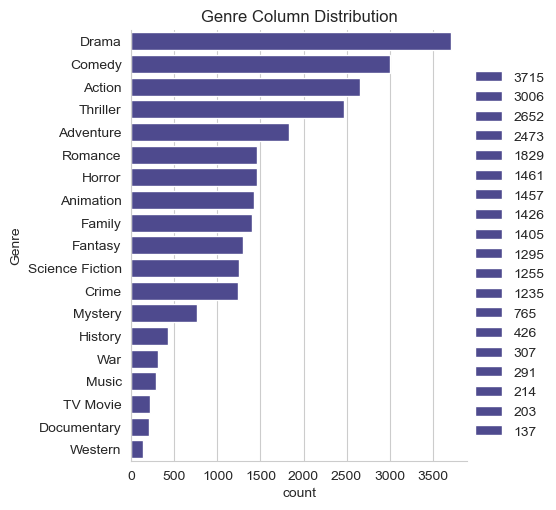

In [119]:
sns.catplot(y='Genre', data = df, kind = 'count', 
           order = df['Genre'].value_counts().index,
           color='#443f99', label=df['Genre'].value_counts())
plt.title('Genre Column Distribution')
plt.show()

* ### The Most frequent Genre in all the released movies is the 'Drama' Genre with value_count of 3715.
* ### The Least frequent Genre in all the released movies is the 'Western' Genre with value_count of 137.

## Q2. Which has the highest votes in the Vote_Average Column ?

In [120]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


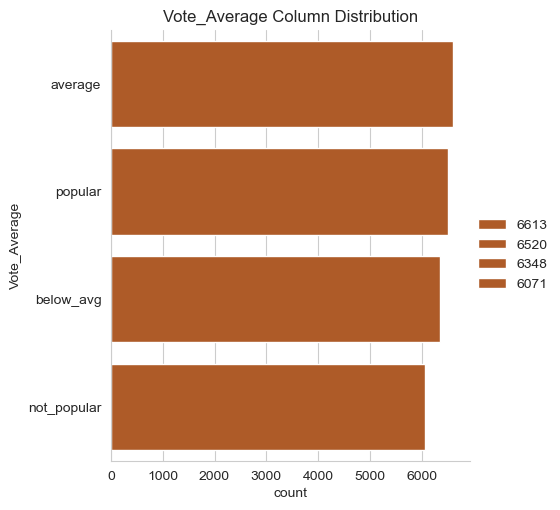

In [121]:
sns.catplot(y='Vote_Average', data=df, kind='count',
           order=df['Vote_Average'].value_counts().index,
           color='#C45612', label=df['Vote_Average'].value_counts())
plt.title('Vote_Average Column Distribution')
plt.show()

+ ### The Highest frequency in Average Votes Column is the 'average' section with frequency of 6613 and least is of 'not_popular' with frequency of 6071.

## Q3. Which movie got the highest popularity and what is its Genre ?

In [123]:
df.sample(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
16218,2020,Captain Underpants: Mega Blissmas,18.409,7,not_popular,Comedy
7144,2016,Moana,33.620,10263,popular,Family


In [124]:
df.describe()

,Release_Date,Popularity,Vote_Count
count,25552.000000,25552.000000,25552.000000
mean,2005.869795,41.973711,1519.017650
std,15.486038,113.758561,2752.000974
min,1902.000000,13.354000,1.000000
25%,2000.000000,16.363000,172.000000
50%,2010.000000,21.844000,498.000000
75%,2017.000000,36.462250,1525.000000
max,2022.000000,5083.954000,31077.000000


In [127]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


+ ### The most popular movie is 'Spider-Man: No Way Home' with Genre 'Action','Adventure','Science Fiction'.

## Q4. Which movie got the lowest popularity and what is its Genre ?

In [130]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


+ ### Their are 2 least popular movies First is 'The United States vs. Billie Holiday' with Genre 'Music','Drama','History' and the second is 'Threads' with Genre 'War', 'Drama', 'Science Fiction'.

## Q5. Which year has the most filmed movies ?

In [133]:
df.sample(4)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
11250,1979,Fearless Hyena,23.797,109,average,Comedy
8536,1995,Rumble in the Bronx,29.248,718,average,Crime
4939,1997,Neon Genesis Evangelion: The End of Evangelion,44.216,1025,popular,Drama
11908,2020,Project Power,22.973,2249,average,Action


In [140]:
df['Release_Date'].describe()

count    25552.000000
mean      2005.869795
std         15.486038
min       1902.000000
25%       2000.000000
50%       2010.000000
75%       2017.000000
max       2022.000000
Name: Release_Date, dtype: float64

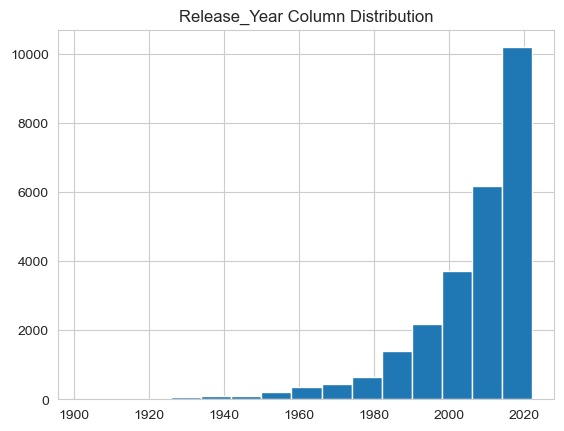

In [147]:
df['Release_Date'].hist(bins=15,label=df['Release_Date'])
plt.title('Release_Year Column Distribution')
plt.show()

+ ### The year 2020 has the most filmed movies.

+ ## Summarization : 

+ 'Drama' Genre has the most frequent Genre in our dataset and has appeared more than 14.53 % of the times among the 19 other genres.
+ We have 25.5 % of our dataset with 'popular' vote (6520) rows. 'Drama' again gets the highest popularity among fans by being having more than 18.5 % movies.
+ 'Spider-Man: No Way Home' has the highest popularity rate in our dataset and it has genres of Action, Adventure and Science Fiction.
+ 'Threads' and 'The United States vs. Billie Holiday' has the lowest popularity rate in the dataset with genre of Music, Drama, History and War, Science fiction, Drama respectively.
+ Year '2020' has the highest filmed movies in the dataset.